In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

# Reloading expression data
filepath = "../data/GSE2034_series_matrix.txt"
expr_df = pd.read_csv(filepath, sep='\t', comment='!', index_col=0)
expr_df.columns = expr_df.columns.str.replace('"', '')

# Reloading clinical data
metadata = {}
with open(filepath, 'r') as f:
    for line in f:
        if line.startswith('!'):
            parts = line.strip().split('\t')
            metadata[parts[0]] = parts[1:]
        elif line.startswith('"ID_REF"'):
            break

clinical_df = pd.DataFrame({
    'sample_id': metadata['!Sample_geo_accession'],
    'relapse': metadata['!Sample_characteristics_ch1']
})
clinical_df['sample_id'] = clinical_df['sample_id'].str.replace('"', '')
clinical_df['relapse'] = clinical_df['relapse'].str.replace('"', '')
clinical_df['relapse'] = clinical_df['relapse'].str.extract(r'(\d)$')
clinical_df = clinical_df.dropna(subset=['relapse'])
clinical_df['relapse'] = clinical_df['relapse'].astype(int)

print("Data reloaded successfully")
print(f"Expression: {expr_df.shape}, Clinical: {clinical_df.shape}")

Data reloaded successfully
Expression: (22283, 286), Clinical: (286, 2)


In [4]:
#re-running the differential expression analysis to get our significant genes back

# Split samples into two groups
relapse_samples = clinical_df[clinical_df['relapse'] == 1]['sample_id'].tolist()
no_relapse_samples = clinical_df[clinical_df['relapse'] == 0]['sample_id'].tolist()

relapse_expr = expr_df[relapse_samples]
no_relapse_expr = expr_df[no_relapse_samples]

# Run t-test for every gene
results = []
for gene in expr_df.index:
    group1 = relapse_expr.loc[gene].values.astype(float)
    group2 = no_relapse_expr.loc[gene].values.astype(float)
    t_stat, p_value = stats.ttest_ind(group1, group2)
    log2fc = np.log2(np.mean(group1) / np.mean(group2))
    results.append({'gene': gene, 'log2_fold_change': log2fc, 'p_value': p_value})

results_df = pd.DataFrame(results).set_index('gene')

# Apply correction
_, p_adjusted, _, _ = multipletests(results_df['p_value'], method='fdr_bh')
results_df['p_adjusted'] = p_adjusted
results_df['significant'] = (results_df['p_adjusted'] < 0.05) & (results_df['log2_fold_change'].abs() > 0.5)

print(f"Significant genes: {results_df['significant'].sum()}")

Significant genes: 63


In [10]:
#Heatmap data

# Get top 50 significant genes
top_genes = results_df[results_df['significant']].sort_values('p_adjusted').head(50)

# Get expression values for those genes
heatmap_data = expr_df.loc[top_genes.index, clinical_df['sample_id']]

# Sort samples by relapse status so relapsed patients are grouped together
clinical_sorted = clinical_df.sort_values('relapse')
heatmap_data = heatmap_data[clinical_sorted['sample_id']]

# Normalize each gene (z-score) correctly
heatmap_normalized = heatmap_data.apply(lambda x: zscore(x), axis=1, result_type='expand')
heatmap_normalized.columns = heatmap_data.columns

print(f"Heatmap data shape: {heatmap_normalized.shape}")


Heatmap data shape: (50, 286)


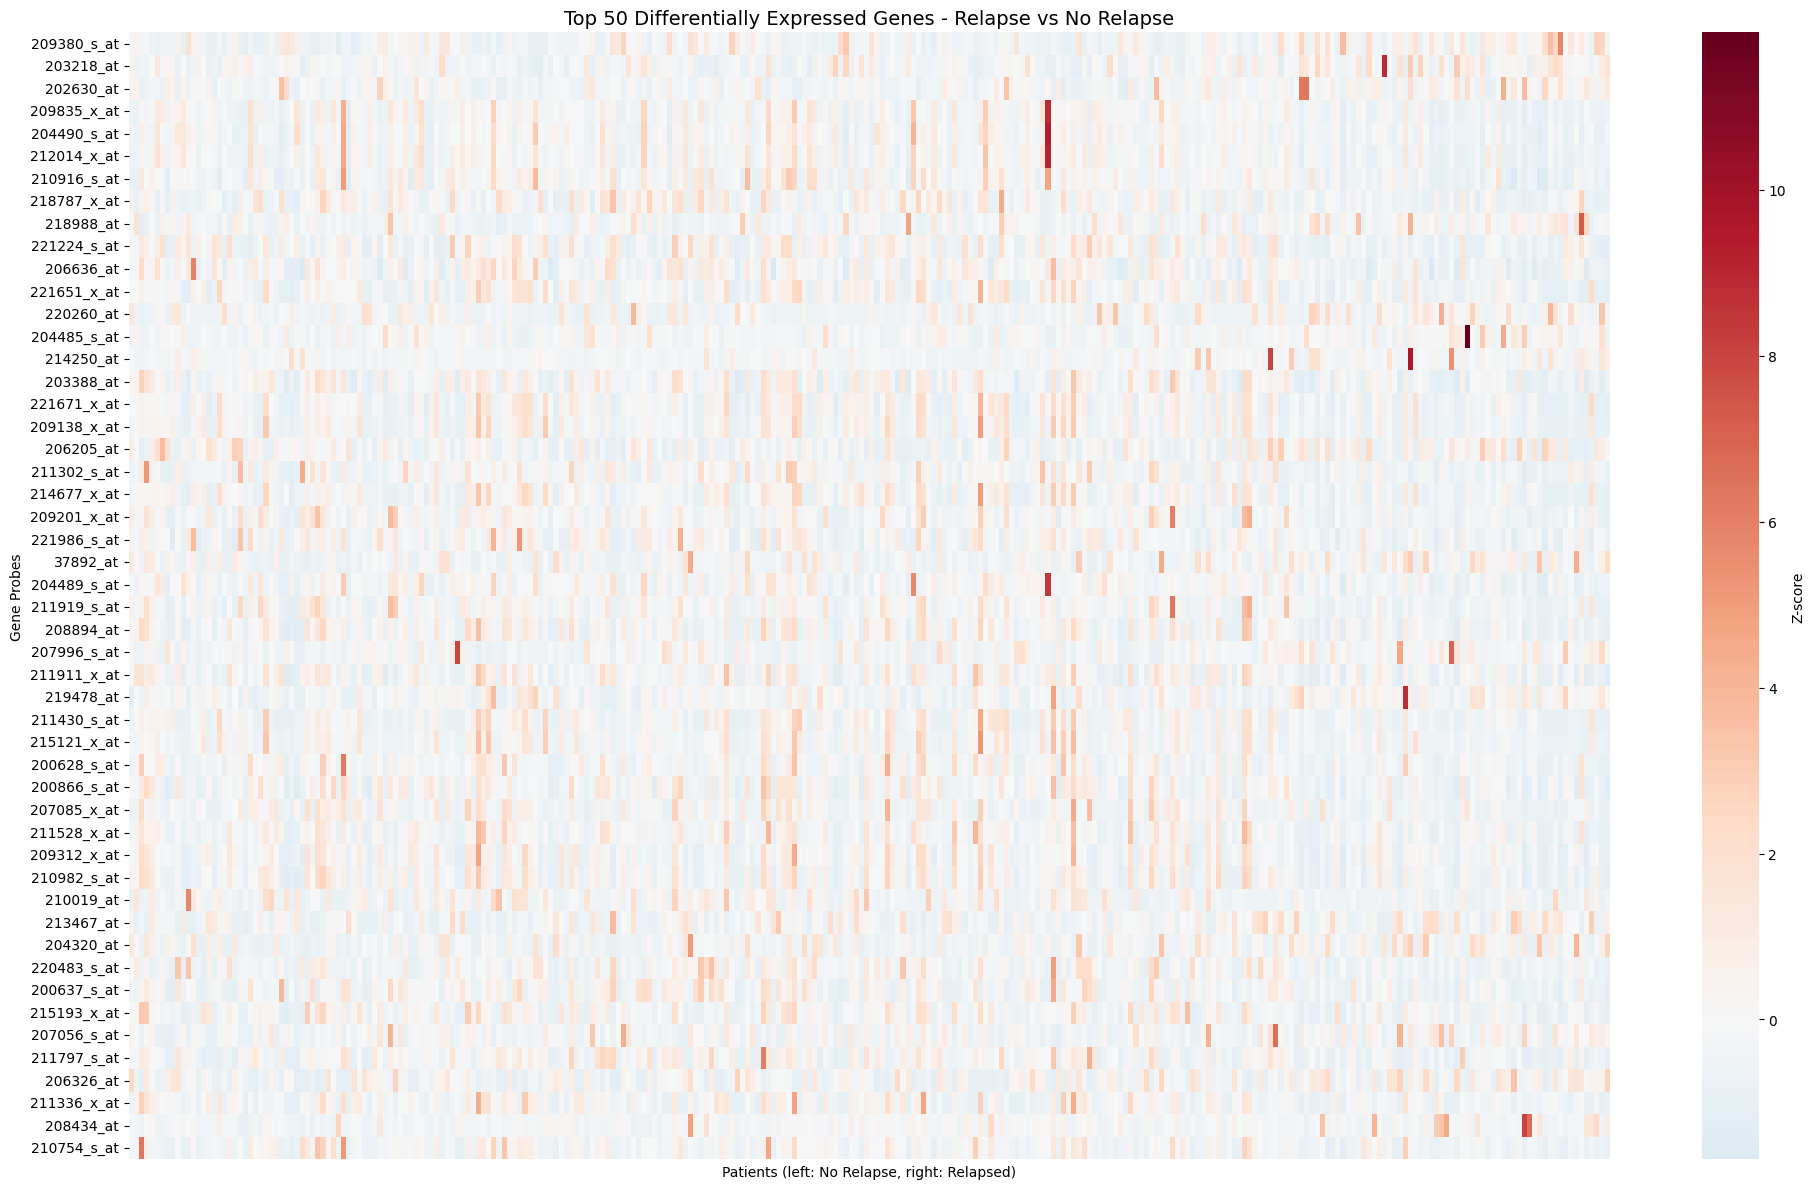

Heatmap saved


In [12]:
# Creating heatmap
plt.figure(figsize=(20, 12))

# color bar for relapse status
relapse_colors = clinical_sorted['relapse'].map({0: 'steelblue', 1: 'salmon'})

sns.heatmap(heatmap_normalized,
            cmap='RdBu_r',
            center=0,
            xticklabels=False,
            yticklabels=True,
            cbar_kws={'label': 'Z-score'})

plt.title('Top 50 Differentially Expressed Genes - Relapse vs No Relapse', fontsize=14)
plt.xlabel('Patients (left: No Relapse, right: Relapsed)')
plt.ylabel('Gene Probes')
plt.tight_layout()
plt.savefig('../data/heatmap.png', dpi=150)
plt.show()
print("Heatmap saved")

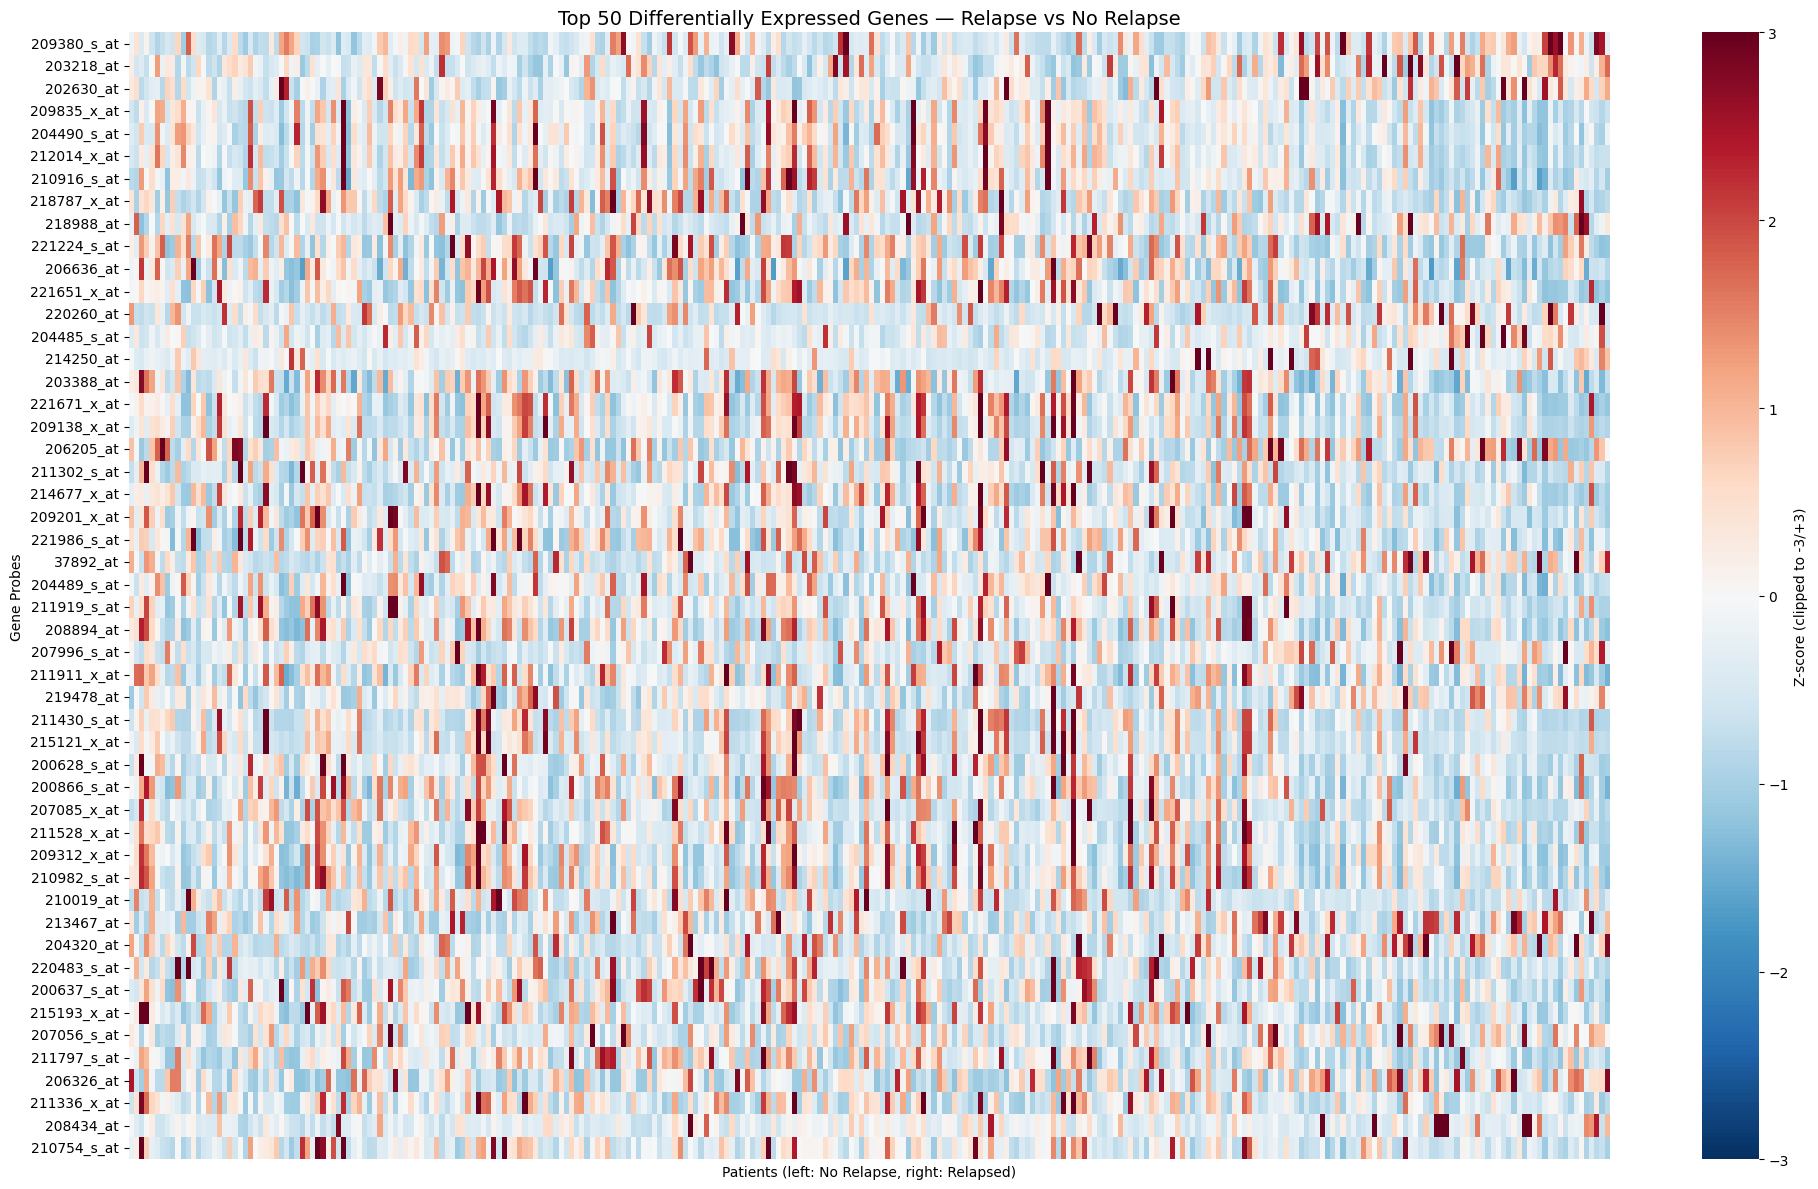

Improved heatmap saved


In [13]:
#heatmap looks a bit washed out, the extreme outlier values are squishing the color scale
#fixing that by capping the z-score range
# Clip extreme values for better visualization
heatmap_clipped = heatmap_normalized.clip(-3, 3)

plt.figure(figsize=(20, 12))

sns.heatmap(heatmap_clipped,
            cmap='RdBu_r',
            center=0,
            vmin=-3, vmax=3,
            xticklabels=False,
            yticklabels=True,
            cbar_kws={'label': 'Z-score (clipped to -3/+3)'})

# Add a color bar on top showing relapse status
ax = plt.gca()
plt.title('Top 50 Differentially Expressed Genes — Relapse vs No Relapse', fontsize=14)
plt.xlabel('Patients (left: No Relapse, right: Relapsed)')
plt.ylabel('Gene Probes')
plt.tight_layout()
plt.savefig('../data/heatmap_improved.png', dpi=150)
plt.show()
print("Improved heatmap saved")

Red - high gene expression (gene is very active in that patient)

Blue - low gene expression (gene is less active)

Each row - one of the top 50 significant genes

Each column - one patient (left = no relapse, right = relapsed)

You can see the pattern isn't perfectly clean (remember the PCA showed the groups overlap). But there are visible differences, especially on the far right where the relapsed patients cluster.

Summary:
1. Reloaded the data
2. Re-ran differential expression
3. Selected top 50 significant genes
4. Got their expression values - sliced the big expression matrix to keep only those 50 genes and all 286 patients.
5. Sorted patients by relapse - reordered the columns so all 217 no-relapse patients come first (left side) and all 69 relapsed patients come last (right side). This makes the heatmap easier to read visually.
6. Z-score normalization - Each gene has different expression ranges, one gene might have values between 100-500 while another is between 2000-8000. If we plotted raw values, the color scale would be dominated by the high-value genes and we'd see nothing useful.
Z-score converts every gene to the same scale:
0 = average expression for that gene
+2 = much higher than average
-2 = much lower than average
So now every gene is comparable on the same color scale.
7. Clipped to -3/+3 - Some patients had extreme outlier values (z-score of 10+) which washed out all the colors. Clipping means anything above 3 becomes 3, anything below -3 becomes -3. This makes the colors more informative across the whole plot.
8. Plotted the heatmap - Red = high expression, Blue = low expression, each row is a gene, each column is a patient.